# Capstone Project I - Mutual Fund Analytics\n
## Day 3: Exploratory Data Analysis (EDA) Dashboard

In [6]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
conn = sqlite3.connect("../bluestock_mf.db")
print("Database connection established successfully!")

Database connection established successfully!


In [ ]:
df_nav_history = pd.read_sql_query("""
    SELECT n.date, f.scheme_name, n.nav 
    FROM fact_nav n 
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
    ORDER BY n.date ASC;
""", conn)

fig1 = px.line(df_nav_history, x='date', y='nav', color='scheme_name', 
              title='Daily NAV Trend Analysis (2022-2026)')

fig1.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1, 
              annotation_text="2023 Bull Run", annotation_position="top left")
fig1.add_vrect(x0="2024-01-01", x1="2024-06-30", fillcolor="red", opacity=0.1, 
              annotation_text="2024 Corrections", annotation_position="top left")

fig1.update_layout(xaxis_title="Date", yaxis_title="NAV (INR)", legend_title="Schemes")
fig1.show()

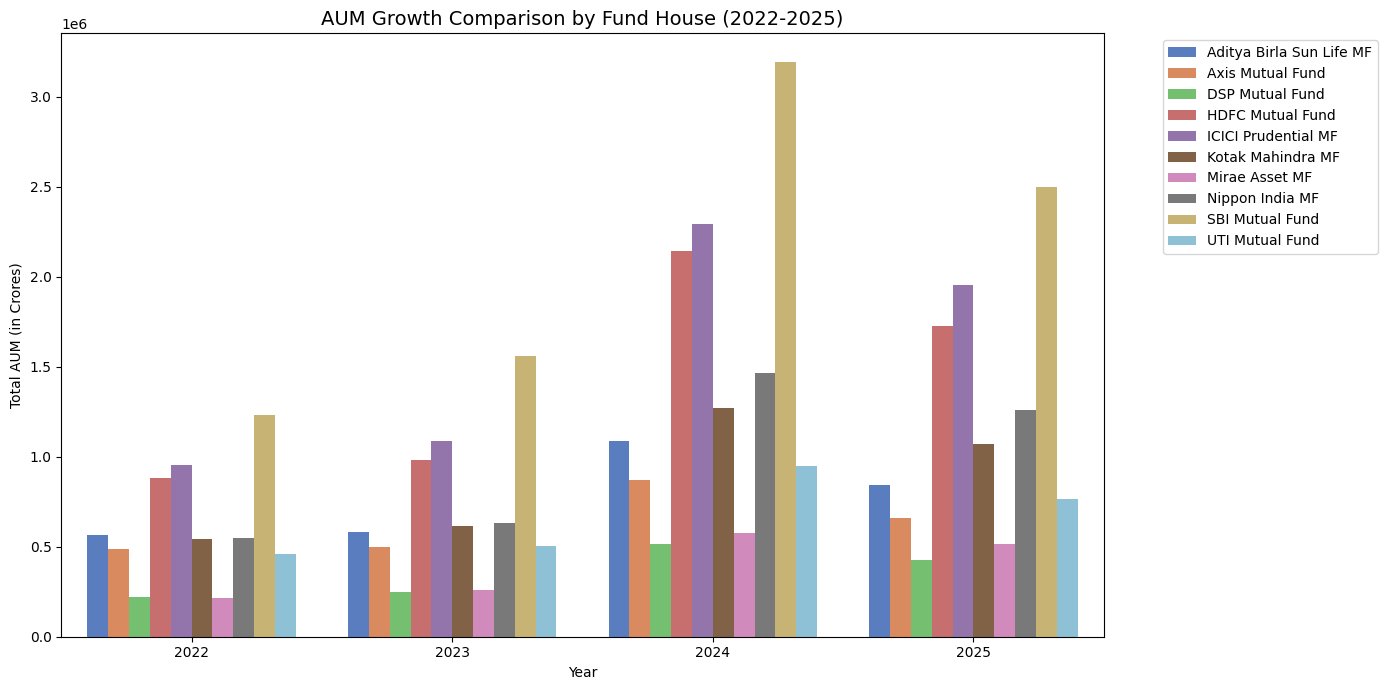

In [8]:
df_aum = pd.read_sql_query("""
    SELECT strftime('%Y', date) as year, fund_house, SUM(aum_crore) as total_aum 
    FROM fact_aum 
    WHERE year BETWEEN '2022' AND '2025'
    GROUP BY year, fund_house;
""", conn)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_aum, x='year', y='total_aum', hue='fund_house', palette='muted')
plt.title('AUM Growth Comparison by Fund House (2022-2025)', fontsize=14)
plt.ylabel('Total AUM (in Crores)')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
df_sip_track = pd.read_csv("C:\\Users\\Mahakaal\\capstone_project\\data\\raw\\04_monthly_sip_inflows.csv")

fig3 = px.line(df_sip_track, x='month', y='sip_inflow_crore', 
              title='Monthly SIP Inflow Time-Series Trends (Jan 2022 - Dec 2025)', markers=True)

fig3.add_annotation(x="2025-12", y=31002, text="All-Time High: ₹31,002 Cr",
                    showarrow=True, arrowhead=2, arrowcolor="red", ax=-50, ay=-40)

fig3.update_layout(xaxis_title="Month", yaxis_title="SIP Inflow (in Crores)")
fig3.show()

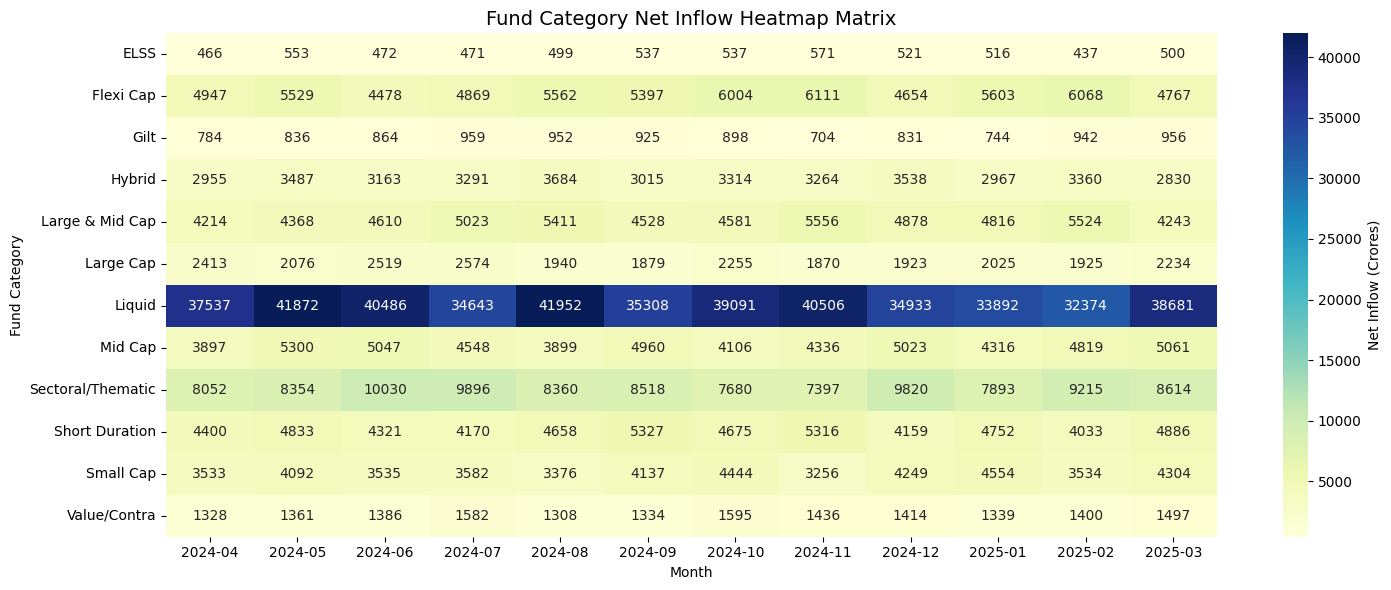

In [13]:
df_cat_inflow = pd.read_csv("C:\\Users\\Mahakaal\\capstone_project\\data\\raw\\05_category_inflows.csv")
pivot_heatmap = df_cat_inflow.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(15, 6))
sns.heatmap(pivot_heatmap, cmap='YlGnBu', annot=True, fmt=".0f", cbar_kws={'label': 'Net Inflow (Crores)'})
plt.title('Fund Category Net Inflow Heatmap Matrix', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.tight_layout()
plt.show()

C:\Users\Mahakaal\AppData\Local\Temp\ipykernel_5668\255181779.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sip_only, x='age_group', y='amount_inr', ax=axes[1], palette='Set2')


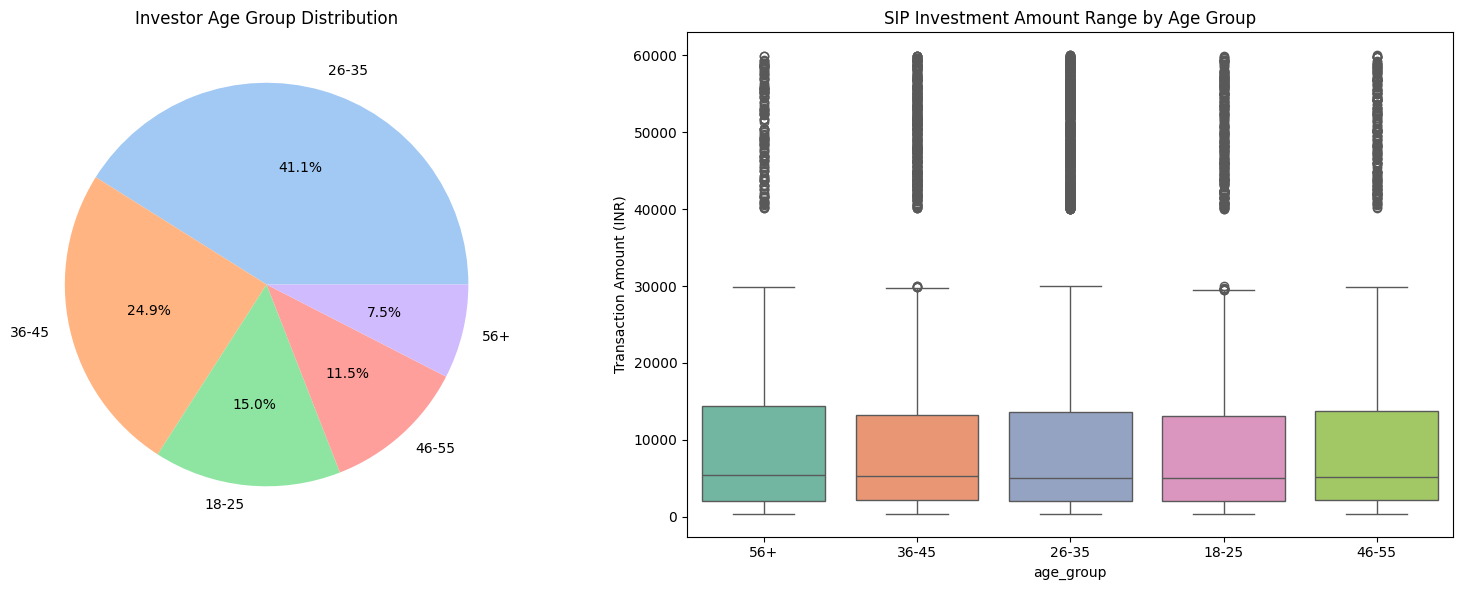

In [14]:
df_tx = pd.read_sql_query("SELECT age_group, gender, amount_inr, transaction_type FROM fact_transactions;", conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Age group distribution pie chart
df_tx['age_group'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[0].set_title('Investor Age Group Distribution')
axes[0].set_ylabel('')

# Chart 2: SIP Amount box plot by age group
df_sip_only = df_tx[df_tx['transaction_type'] == 'SIP']
sns.boxplot(data=df_sip_only, x='age_group', y='amount_inr', ax=axes[1], palette='Set2')
axes[1].set_title('SIP Investment Amount Range by Age Group')
axes[1].set_ylabel('Transaction Amount (INR)')

plt.tight_layout()
plt.show()

# Chart 3: Gender Split Pie Chart via Plotly
fig_gender = px.pie(df_tx, names='gender', title='Investor Base Gender Breakdown Split', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_gender.show()

In [15]:
df_geo = pd.read_sql_query("SELECT state, city_tier, amount_inr FROM fact_transactions WHERE transaction_type='SIP';", conn)

# Chart 1: Horizontal bar chart of SIP amount by state
df_state = df_geo.groupby('state')['amount_inr'].sum().reset_index().sort_values(by='amount_inr', ascending=True)
fig_state = px.bar(df_state, x='amount_inr', y='state', orientation='h', title='Total SIP Inflow Volumes Grouped by State')
fig_state.show()

# Chart 2: T30 vs B30 Tier Split
fig_tier = px.pie(df_geo, names='city_tier', title='Transaction Inflows Breakdown: T30 vs B30 Cities')
fig_tier.show()

In [18]:
df_folios = pd.read_csv("C:\\Users\\Mahakaal\\capstone_project\\data\\raw\\06_industry_folio_count.csv")

fig7 = px.line(df_folios, x='month', y='total_folios_crore', title='Mutual Fund Industry Folio Growth History', markers=True)
fig7.add_annotation(x="2022-01", y=13.26, text="Jan 2022 Base: 13.26 Cr", showarrow=True, arrowhead=1)
fig7.add_annotation(x="2025-12", y=26.12, text="Dec 2025 Peak: 26.12 Cr", showarrow=True, arrowhead=1, ax=-40, ay=-30)
fig7.show()

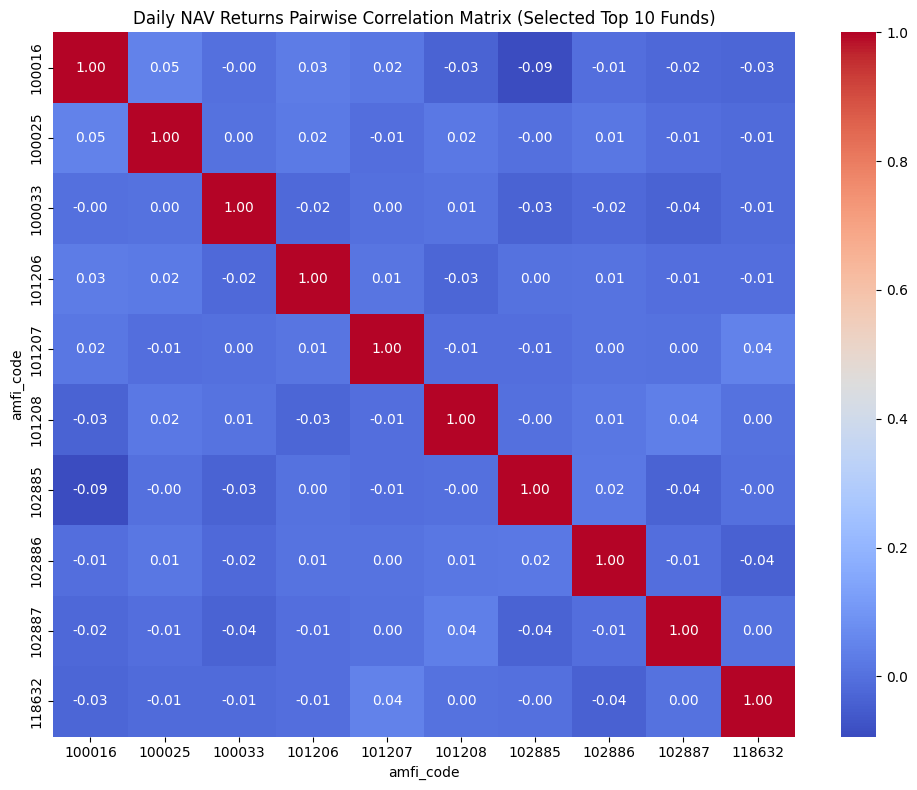

In [ ]:
# Pivot NAV table to get daily returns per fund scheme
df_nav_pivot = pd.read_sql_query("SELECT date, amfi_code, nav FROM fact_nav;", conn)
df_pivot = df_nav_pivot.pivot(index='date', columns='amfi_code', values='nav').dropna()

# Compute daily percent returns percentage changes
df_returns = df_pivot.pct_change().dropna()

correlation_matrix = df_returns.iloc[:, :10].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Daily NAV Returns Pairwise Correlation Matrix (Selected Top 10 Funds)')
plt.tight_layout()
plt.show()

In [21]:
df_holdings = pd.read_csv("C:\\Users\\Mahakaal\\capstone_project\\data\\raw\\09_portfolio_holdings.csv")
df_sectors = df_holdings.groupby('sector')['weight_pct'].mean().reset_index()

fig9 = px.pie(df_sectors, values='weight_pct', names='sector', hole=0.4,
             title='Aggregated Industry Sector Allocation Weights Across Equity Funds')
fig9.update_traces(textinfo='percent+label')
fig9.show()